## Recency Frequency Monetary (RFM) Analysis using Hierarchical Clustering from the year 2020 to 2023
### Introduction: Customer Segmentation using RFM Analysis

All imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
import seaborn as sns
from sklearn.discriminant_analysis import StandardScaler
import warnings
from scipy import stats
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
warnings.filterwarnings("ignore")

Input the location of the dataset to run the folder

In [3]:
path = '../Data/Intuilize_MNSU_SampleSales_V1_011524 - Intuilize_SampleSales_V1_011524.csv'

### 1. Exploratory Data Analysis

Read in the data

In [4]:
df = pd.read_csv(path)
df.head()

,LocationID,LocationName,BranchID,BranchName,InvoiceNumber,ProductGroup,ProductCode,CustomerName,CustomerCode,SalesDate,ExtCost,ExtPrice,SalesQty,UnitCost,UnitPrice,GM%
0,1,Dallas,1,ACME Inc,1320612,Electrical,AAA88,Dickinson-Fay,17314,8/11/2021,"$1,685.15","$2,286.99",10.0,$168.5150,$228.6989,26.32
1,1,Dallas,1,ACME Inc,1320619,Electrical,AAA9A,Grimes-Grimes,17373,8/11/2021,$52.74,$90.15,10.0,$5.2743,$9.0149,41.49
2,1,Dallas,1,ACME Inc,1320621,Electrical,AA459,Goyette-Legros,18145,8/11/2021,$41.31,$59.02,1.0,$41.3138,$59.0197,30.00
3,1,Dallas,1,ACME Inc,1320621,Electrical,AA567,Goyette-Legros,18145,8/11/2021,$8.78,$13.46,1.0,$8.7770,$13.4642,34.81
4,1,Dallas,1,ACME Inc,1320622,Electrical,AA570,Lockman-Prosacco,12908,8/11/2021,$49.97,$64.62,2.0,$24.9847,$32.3090,22.67


Creating the dataframe and clean the data

In [5]:
def cleanCurrency(df, columns):
    for col in columns:
        df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)
    
def cleanDate(df, columns):
    for col in columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    

def createRFMDataFrame(df):
    # Create a new dataframe with the necessary columns
    rfm = df.groupby('CustomerCode').agg({'SalesDate': lambda date: (df['SalesDate'].max() - date.max()).days,
                                         'InvoiceNumber': lambda num: len(num),
                                         'ExtPrice': lambda price: price.sum()})

    # Convert the SalesDate to int
    rfm['SalesDate'] = rfm['SalesDate'].astype(int)

    # Rename the columns
    rfm.rename(columns={'SalesDate': 'Recency', 
                        'InvoiceNumber': 'Frequency', 
                        'ExtPrice': 'Monetary'}, inplace=True)

    return rfm

cleanCurrency(df, ['ExtPrice', 'ExtCost', 'UnitCost', 'UnitPrice'])
cleanDate(df, ['SalesDate'])
rfm = createRFMDataFrame(df)
rfm.head()
# Adding 1 to the zeroes to avoid issues with log transformation
rfm['Recency'] = rfm['Recency'].apply(lambda x: x+1)

In [6]:
rfm.head()

,Recency,Frequency,Monetary
CustomerCode,,,
12346,92,3,7535.10
12347,537,2,3017.45
12348,9,102,755281.56
12350,12,300,38223.76
12352,2,78,9454.96


## 2. Data Preprocessing and Transformation.

Using box cox transformation to reduce the skewness of the data

In [7]:
def fix_skewness(df, columns):
    """
    Fix skewness in specified columns of a DataFrame using Box-Cox transformation.

    Parameters:
    - df: DataFrame: Input DataFrame
    - columns: list of str: List of column names to fix skewness

    Returns:
    - df_fixed: DataFrame: DataFrame with skewness fixed in specified columns
    """
    df_fixed = pd.DataFrame()
    for column in columns:
        df_fixed[column] = stats.boxcox(df[column])[0]
    return df_fixed

# Example usage:
rfm_columns = ['Recency', 'Frequency', 'Monetary']
customers_fix = fix_skewness(rfm, rfm_columns)
customers_fix.tail()

,Recency,Frequency,Monetary
2403,14.425057,0.659584,4.138178
2404,12.675106,1.015893,5.221679
2405,16.933552,0.000000,5.712618
2406,15.524461,1.696400,4.592656
2407,15.449071,1.882744,7.631539


Normalizing the RFM Values

In [8]:
def scaleData(data):
    scaler = StandardScaler()
    scaler.fit(data)
    scaler.transform(data)
    return scaler.transform(data)
customer_normalized = scaleData(customers_fix)
print(customer_normalized.mean(axis = 0).round(2))
print(customer_normalized.std(axis = 0).round(2))

[-0.  0. -0.]
[1. 1. 1.]


## 3. Modeling the Data with Hierarchical Clustering

In [9]:
model = AgglomerativeClustering(distance_threshold=40, n_clusters=None)
predict = model.fit_predict(customer_normalized)

In [10]:
rfm['Segment'] = predict

In [11]:
rfm['Segment'].value_counts()

Segment
0    915
1    827
2    666
Name: count, dtype: int64

In [12]:
rfm_fig = rfm.copy()
rfm_fig['Frequency'] = np.log(rfm_fig['Frequency'])
rfm_fig['Recency'] = np.log(rfm_fig['Recency'])
rfm_fig['Monetary'] = np.cbrt(rfm_fig['Monetary'])
rfm_fig.head()

,Recency,Frequency,Monetary,Segment
CustomerCode,,,,
12346,4.521789,1.098612,19.604827,0
12347,6.285998,0.693147,14.450405,0
12348,2.197225,4.624973,91.068803,1
12350,2.484907,5.703782,33.685614,1
12352,0.693147,4.356709,21.145594,1


## 4. Visualizing the clusters

Exploring the clusters and their visualizations

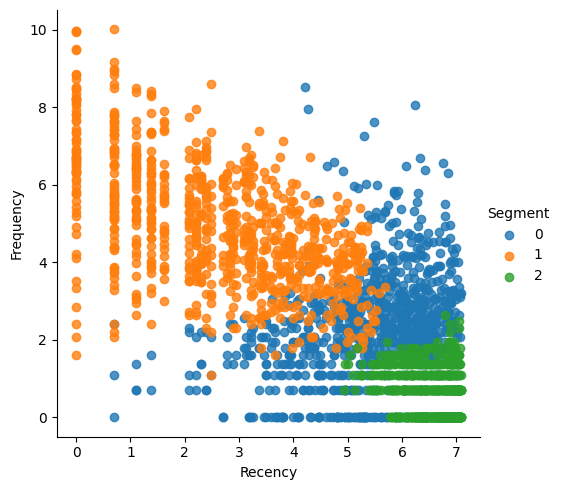

In [13]:
sns.lmplot(data=rfm_fig, x='Recency', y='Frequency', hue='Segment', fit_reg=False)

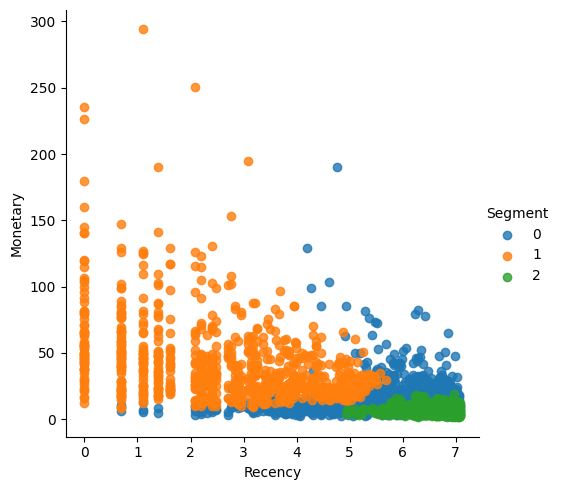

In [14]:
sns.lmplot(data=rfm_fig, x='Recency', y='Monetary', hue='Segment',fit_reg=False)

Plotting the dendograms to visualize the clusters

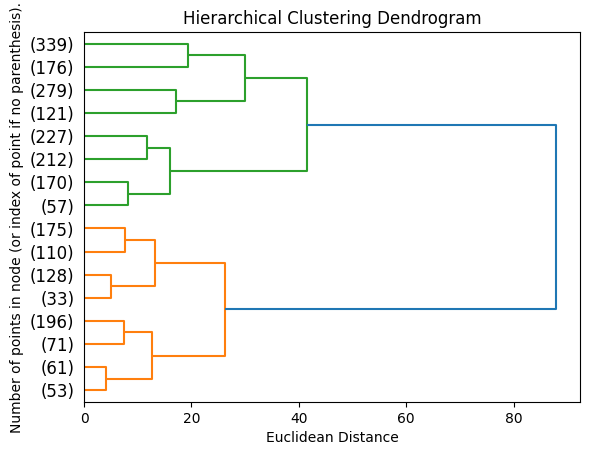

In [15]:
def plot_dendrogram(model, **kwargs):
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, orientation='right',**kwargs)


plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(model,truncate_mode='level', p=3)
plt.xlabel("Euclidean Distance")
plt.ylabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

In [16]:
numerical_features = rfm[['Recency', 'Frequency', 'Monetary']]
quantiles = numerical_features.quantile(q=[0.2,0.4,0.6,0.8])
quantiles = quantiles.to_dict()


'''
Recency Score.
Assigns Scores based on the quantile levels.
Customers who have purchased more recently get a higher score.
'''
def RScore(x,p,d):
    if x <= d[p][0.2]:
        return 5
    elif x <= d[p][0.4]:
        return 4
    elif x <= d[p][0.6]: 
        return 3
    elif x <= d[p][0.8]: 
        return 2
    else:
        return 1   
    
'''
Frequency and Monetary Score.
Assigns Scores based on the quantile levels but in reverse.
'''
def FMScore(x,p,d):
    if x <= d[p][0.2]:
        return 1
    elif x <= d[p][0.4]:
        return 2
    elif x <= d[p][0.6]: 
        return 3
    elif x <= d[p][0.8]: 
        return 4
    else:
        return 5
    
rfm['R'] = rfm['Recency'].apply(RScore, args=('Recency',quantiles,))
rfm['F'] = rfm['Frequency'].apply(FMScore, args=('Frequency',quantiles,))
rfm['M'] = rfm['Monetary'].apply(FMScore, args=('Monetary',quantiles,))
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

In [17]:
def assign_bucket(rfm_score):
    if rfm_score > 12:
        return 'Platinum'
    elif rfm_score <= 12 and rfm_score > 9:
        return 'Gold'
    elif rfm_score <= 9 and rfm_score > 6:
        return 'Silver'
    elif rfm_score <= 6 and rfm_score > 3:
        return 'Bronze'
    else:
        return 'Silicone'

buckets = ['Platinum', 'Gold', 'Silver', 'Bronze', 'Silicone']
rfm['Segments'] = rfm['RFM_Score'].apply(assign_bucket)
rfm.head()

,Recency,Frequency,Monetary,Segment,R,F,M,RFM_Score,Segments
CustomerCode,,,,,,,,,
12346,92,3,7535.10,0,4,2,4,10,Gold
12347,537,2,3017.45,0,2,1,3,6,Bronze
12348,9,102,755281.56,1,5,4,5,14,Platinum
12350,12,300,38223.76,1,5,5,5,15,Platinum
12352,2,78,9454.96,1,5,4,4,13,Platinum
